# Импорты

In [2]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

In [4]:
from pymatgen.analysis.eos import EOS

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar

from pymatgen.electronic_structure.core import Spin

In [5]:
import warnings

In [6]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [7]:
pd.set_option('display.float_format', '{:.2e}'.format)

#### Импорт файлов серии расчетов

In [8]:
Ni3Al_INCAR = Incar.from_file("44/INCAR")

In [9]:
df_incar = pd.DataFrame({
    'Ni3Al': dict(Ni3Al_INCAR)
}).fillna('')

df_incar

,Ni3Al
SYSTEM,Ni3Al EOS
PREC,Accurate
NCORE,4
LREAL,False
LWAVE,False
LASPH,True
ADDGRID,True
SYMPREC,1.00e-05
ISYM,2
ISPIN,2


In [10]:
# a = 3.44
Ni3Al_44_Outcar = Outcar("44/result/OUTCAR")
Ni3Al_44_vasprun = Vasprun("44/result/vasprun.xml")

# a = 3.47
Ni3Al_47_Outcar = Outcar("47/result/OUTCAR")
Ni3Al_47_vasprun = Vasprun("47/result/vasprun.xml")

# a = 3.50
Ni3Al_50_Outcar = Outcar("50/result/OUTCAR")
Ni3Al_50_vasprun = Vasprun("50/result/vasprun.xml")

# a = 3.53
Ni3Al_53_Outcar = Outcar("53/result/OUTCAR")
Ni3Al_53_vasprun = Vasprun("53/result/vasprun.xml")

# a = 3.56
Ni3Al_56_Outcar = Outcar("56/result/OUTCAR")
Ni3Al_56_vasprun = Vasprun("56/result/vasprun.xml")

# a = 3.59
Ni3Al_59_Outcar = Outcar("59/result/OUTCAR")
Ni3Al_59_vasprun = Vasprun("59/result/vasprun.xml")

# a = 3.62
Ni3Al_62_Outcar = Outcar("62/result/OUTCAR")
Ni3Al_62_vasprun = Vasprun("62/result/vasprun.xml")

# a = 3.65
Ni3Al_65_Outcar = Outcar("65/result/OUTCAR")
Ni3Al_65_vasprun = Vasprun("65/result/vasprun.xml")

# a = 3.68
Ni3Al_68_Outcar = Outcar("68/result/OUTCAR")
Ni3Al_68_vasprun = Vasprun("68/result/vasprun.xml")

In [11]:
# run_01 - Al и Ni для вычисления энтальпии образования
Ni_01_Outcar = Outcar("../VASP_run_01/Ni/result/OUTCAR")
Al_01_Outcar = Outcar("../VASP_run_01/Al/result/OUTCAR")

In [12]:
outcars = [
    Ni3Al_44_Outcar,
    Ni3Al_47_Outcar,
    Ni3Al_50_Outcar,
    Ni3Al_53_Outcar,
    Ni3Al_56_Outcar,
    Ni3Al_59_Outcar,
    Ni3Al_62_Outcar,
    Ni3Al_65_Outcar,
    Ni3Al_68_Outcar
]

vaspruns = [
    Ni3Al_44_vasprun, Ni3Al_47_vasprun, Ni3Al_50_vasprun,
    Ni3Al_53_vasprun, Ni3Al_56_vasprun, Ni3Al_59_vasprun,
    Ni3Al_62_vasprun, Ni3Al_65_vasprun, Ni3Al_68_vasprun
]

a_values = [3.44, 3.47, 3.50, 3.53, 3.56, 3.59, 3.62, 3.65, 3.68]

In [13]:
df_kpoints = pd.DataFrame({
    'Система': ['Ni3Al'],
    'N k-точек': [len(vaspruns[0].actual_kpoints)],
    'K-сетка': [f"{vaspruns[0].kpoints.kpts[0][0]}×{vaspruns[0].kpoints.kpts[0][1]}×{vaspruns[0].kpoints.kpts[0][2]}"]
})
df_kpoints

,Система,N k-точек,K-сетка
0,Ni3Al,220,18×18×18


# Проверка сходимости электронного и ионного цикла

In [14]:
pd.set_option('display.float_format', '{:3}'.format)

df_stats = pd.DataFrame([
    {**outcar.run_stats, 'a': a} 
    for a, outcar in zip(a_values, outcars)
])

df_stats = df_stats.set_index('a')
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores
a,,,,,,,
3.44,None,127524.0,85.124,8.216,74.602,82.817,24
3.47,None,128204.0,89.508,7.816,79.408,87.224,24
3.5,None,132872.0,545.748,25.435,255.146,280.581,24
3.53,None,126952.0,76.108,6.913,66.97,73.883,24
3.56,None,129472.0,79.778,7.101,70.32,77.421,24
3.59,None,135180.0,84.236,8.046,73.898,81.944,24
3.62,None,137512.0,82.414,7.73,71.979,79.709,24
3.65,None,134568.0,81.007,7.962,71.444,79.406,24
3.68,None,134788.0,84.254,8.399,74.146,82.544,24


## Электронный цикл

In [15]:
data = []
for a, vasp in zip(a_values, vaspruns):
    ionic_steps = vasp.ionic_steps
    if ionic_steps:
        last_ionic = ionic_steps[-1]
        electronic_steps = last_ionic['electronic_steps']
        for i in range(1, len(electronic_steps)):
            d = abs(electronic_steps[i]['e_fr_energy'] - electronic_steps[i-1]['e_fr_energy'])
            data.append((a, i, d))

df_delta_e = pd.DataFrame(data, columns=['a (Å)', 'Итерация', '|ΔE| (эВ)'])
pd.options.display.float_format = '{:.10f}'.format
df_delta_e

,a (Å),Итерация,|ΔE| (эВ)
0,3.4400000000,1,180.1241796400
1,3.4400000000,2,4.5131495600
2,3.4400000000,3,0.0413421200
3,3.4400000000,4,0.0010016900
4,3.4400000000,5,0.0013992600
...,...,...,...
130,3.6800000000,11,0.0000358200
131,3.6800000000,12,0.0000063800
132,3.6800000000,13,0.0000028600
133,3.6800000000,14,0.0000012400


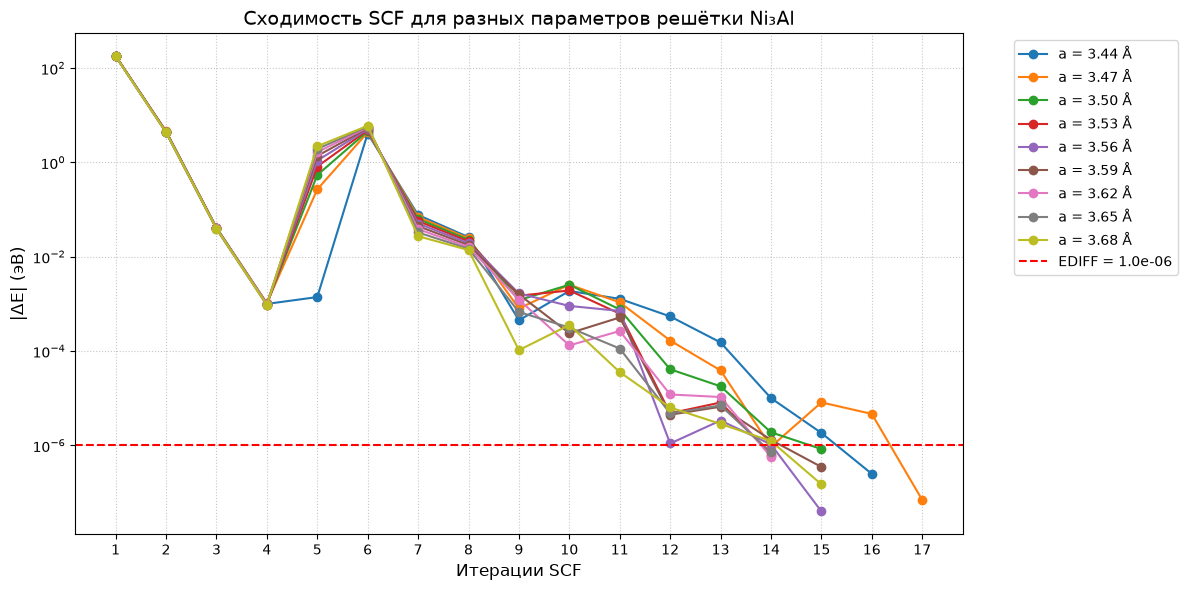

In [16]:
EDIFF = Ni3Al_INCAR.get('EDIFF')

plt.figure(figsize=(12, 6))

for a in sorted(df_delta_e['a (Å)'].unique()):
    sub = df_delta_e[df_delta_e['a (Å)'] == a]
    plt.plot(sub['Итерация'], sub['|ΔE| (эВ)'], 'o-', label=f'a = {a:.2f} Å')

plt.axhline(EDIFF, color='r', linestyle='--', label=f'EDIFF = {EDIFF:.1e}')
plt.yscale('log')
plt.xlabel('Итерации SCF', fontsize=12)
plt.ylabel('|ΔE| (эВ)', fontsize=12)
plt.title('Сходимость SCF для разных параметров решётки Ni₃Al', fontsize=14)
plt.xticks(sorted(df_delta_e['Итерация'].unique()))

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Ионный цикл

In [17]:
data_ion_forces = []
for a, vasp in zip(a_values, vaspruns):
    for i, step in enumerate(vasp.ionic_steps):
        forces = step['forces']
        max_force = max(abs(f) for atom in forces for f in atom)
        data_ion_forces.append({
            'a (Å)': a,
            'Ионный шаг': i,
            '|F_max| (эВ/Å)': max_force
        })

df_ion_forces = pd.DataFrame(data_ion_forces)
df_ion_forces

,a (Å),Ионный шаг,|F_max| (эВ/Å)
0,3.4400000000,0,0.0000000000
1,3.4700000000,0,0.0000000000
2,3.5000000000,0,0.0000000000
3,3.5300000000,0,0.0000000000
4,3.5600000000,0,0.0000000000
5,3.5900000000,0,0.0000000000
6,3.6200000000,0,0.0000000000
7,3.6500000000,0,0.0000000000
8,3.6800000000,0,0.0000000000


# Уравнение состояния

In [18]:
energies = [out.final_energy for out in outcars]  # total energy (эВ)
volumes = [a**3 for a in a_values] # ISIF=2

eos = EOS(eos_name='birch_murnaghan')
fit = eos.fit(volumes, energies)

v0 = fit.v0
e0 = fit.e0
b0 = fit.b0
b0_GPa = fit.b0_GPa
b1 = fit.b1
a0 = v0 ** (1/3)

print(f"Равновесный объём V0 = {v0:.4f} Å³")
print(f"Минимальная энергия E0 = {e0:.6f} эВ")
print(f"Объёмный модуль упругости B0 = {b0_GPa:.2f} ГПа")
print(f"Производная B0' (dK/dP) = {b1:.3f}")
print(f"Равновесный параметр решётки a0 = {a0:.4f} Å")

Равновесный объём V0 = 45.5442 Å³
Минимальная энергия E0 = -22.216574 эВ
Объёмный модуль упругости B0 = 178.89 ГПа
Производная B0' (dK/dP) = 4.622
Равновесный параметр решётки a0 = 3.5712 Å


In [19]:
def P_BM(V, V0, B0, Bp):
    eta = (V / V0) ** (-2/3)
    return 1.5 * B0 * (eta**3 - eta**2) * (1 + 0.75 * (Bp - 4) * (eta - 1))

df_dft = pd.DataFrame({
    'V (Å³)': volumes,
    'V / V₀': np.array(volumes) / v0,
    'P (ГПа)': P_BM(np.array(volumes), float(v0), float(b0_GPa), float(b1))
}, index=pd.Index(a_values, name='a (Å)'))
df_comp = df_dft[df_dft['V / V₀'] <= 1.0]

df_dft

,V (Å³),V / V₀,P (ГПа)
a (Å),,,
3.4400000000,40.7075840000,0.8938038386,25.0995678738
3.4700000000,41.7819230000,0.9173927679,18.3010279227
3.5000000000,42.8750000000,0.9413931217,12.1777400574
3.5300000000,43.9869770000,0.9658084570,6.6673550118
3.5600000000,45.1180160000,0.9906423307,1.7134478728
3.5900000000,46.2682790000,1.0158982998,-2.7350757110
3.6200000000,47.4379280000,1.0415799213,-6.7245101669
3.6500000000,48.6271250000,1.0676907523,-10.2968246084
3.6800000000,49.8360320000,1.0942343496,-13.4900876946


In [20]:
doi = pd.DataFrame({
    'a₀ (Å)': [3.57, 3.48, 3.57],
    'V₀ (Å³)': [45.37, 42.17, 45.58],
    'B₀ (ГПа)': [np.nan, np.nan, 179.3],
}, index=['GGA', 'LDA', 'Эксперимент'])
doi.loc['Наши результаты'] = [a0, v0, b0_GPa]

eid = pd.DataFrame({
    'a₀ (Å)': [3.5609, 3.4862, 3.572],
    'V₀ (Å³)': [3.5609**3, 3.4862**3, 3.572**3],
    'B₀ (ГПа)': [184.49, 223.02, 171.0],
    "B₀'": [4.520, 4.560, np.nan],
}, index=['GGA', 'LDA', 'Эксперимент'])
eid.loc['Наши результаты'] = [a0, v0, b0_GPa, b1]

cols = [('a₀ (Å)', 'a₀'), ('V₀ (Å³)', 'V₀'), ('B₀ (ГПа)', 'B₀')]
for df in (doi, eid):
    exp = df.loc['Эксперимент']
    for c, k in cols:
        df[f'Δ{k} от эксп. (%)'] = ((df[c] - exp[c]) / exp[c] * 100).round(4)

df_all = pd.concat([doi, eid], keys=['DOI: 10.1088/1757-899X/338/1/012041', 'EID: 2-s2.0-80053137277'], names=['Источник'])
df_all 

a₀ (Å)  \
Источник                                                           
DOI: 10.1088/1757-899X/338/1/012041 GGA             3.5700000000   
                                    LDA             3.4800000000   
                                    Эксперимент     3.5700000000   
                                    Наши результаты 3.5711742169   
EID: 2-s2.0-80053137277             GGA             3.5609000000   
                                    LDA             3.4862000000   
                                    Эксперимент     3.5720000000   
                                    Наши результаты 3.5711742169   

                                                          V₀ (Å³)  \
Источник                                                            
DOI: 10.1088/1757-899X/338/1/012041 GGA             45.3700000000   
                                    LDA             42.1700000000   
                                    Эксперимент     45.5800000000   
                                    Наши результаты 45.5442035976   
EID: 2-s2.0-80053137277             GGA             45.1522433715   
                                    LDA             42.3698469919   
                                    Эксперимент     45.5758052480   
                                    Наши результаты 45.5442035976   

                                                          B₀ (ГПа)  \
Источник                                                             
DOI: 10.1088/1757-899X/338/1/012041 GGA                        NaN   
                                    LDA                        NaN   
                                    Эксперимент     179.3000000000   
                                    Наши результаты 178.8900845197   
EID: 2-s2.0-80053137277             GGA             184.4900000000   
                                    LDA             223.0200000000   
                                    Эксперимент     171.0000000000   
                                    Наши результаты 178.8900845197   

                                                     Δa₀ от эксп. (%)  \
Источник                                                                
DOI: 10.1088/1757-899X/338/1/012041 GGA                  0.0000000000   
                                    LDA                 -2.5210000000   
                                    Эксперимент          0.0000000000   
                                    Наши результаты      0.0329000000   
EID: 2-s2.0-80053137277             GGA                 -0.3108000000   
                                    LDA                 -2.4020000000   
                                    Эксперимент          0.0000000000   
                                    Наши результаты     -0.0231000000   

                                                     ΔV₀ от эксп. (%)  \
Источник                                                                
DOI: 10.1088/1757-899X/338/1/012041 GGA                 -0.4607000000   
                                    LDA                 -7.4814000000   
                                    Эксперимент          0.0000000000   
                                    Наши результаты     -0.0785000000   
EID: 2-s2.0-80053137277             GGA                 -0.9294000000   
                                    LDA                 -7.0343000000   
                                    Эксперимент          0.0000000000   
                                    Наши результаты     -0.0693000000   

                                                     ΔB₀ от эксп. (%)  \
Источник                                                                
DOI: 10.1088/1757-899X/338/1/012041 GGA                           NaN   
                                    LDA                           NaN   
                                    Эксперимент          0.0000000000   
                                    Наши результаты     -0.2286000000   
EID: 2-s2.0-80053137277             GGA                  7.8889000000   
            

Расчёт Ni₃Al (L1₂) методом PAW-PBE даёт параметры EOS ($a_0 = 3.5712$ Å, $V_0 = 45.54$ Å³, $B_0 = 178.89$ ГПа, $B_0' = 4.622$), которые хорошо согласуются с экспериментальными данными обоих источников: отклонение от эксперимента из [DOI: 10.1088/1757-899X/338/1/012041](https://www.researchgate.net/publication/324420744_Density_Functional_Theory_Study_of_Structural_and_Electronic_Properties_ofg%27-Ni3Al_andg-Ni3Nb) ($V_0 = 45.58$ Å³, $B_0 = 179.3$ ГПа) не превышает 0.23\%, от эксперимента из [EID: 2-s2.0-80053137277](https://www.researchgate.net/publication/249616445_Study_of_structural_elastic_electronic_optical_and_thermal_properties_of_Ni3Al) ($a_0 = 3.572$ Å, $B_0 = 171.0$ ГПа) — 4.61\% по $B_0$. Теоретические GGA и LDA из обоих источников систематически завышают $B_0$ (до +30\% для LDA по EID), что указывает на то, что PBE-потенциал в данной реализации точнее воспроизводит упругие свойства Ni₃Al, чем функционалы из литературы.

## График зависимости давления от нормированного объёма

In [21]:
v_lo = df_dft['V / V₀'].min() - 0.05
v_norm_smooth = np.linspace(v_lo, 1.0, 200)
v_norm_full = np.linspace(v_lo, df_dft['V / V₀'].max() + 0.05, 200)

eid_lit = {m: eid.loc[m] for m in ['GGA', 'LDA']}

df_lit_EID = pd.concat([
    pd.DataFrame({
        'V / V₀': v_norm_smooth,
        'P (ГПа)': P_BM(v_norm_smooth * p['V₀ (Å³)'], p['V₀ (Å³)'], p['B₀ (ГПа)'], p["B₀'"]),
        'Метод': method
    }) for method, p in eid_lit.items()
], ignore_index=True)

df_gga = df_lit_EID[df_lit_EID['Метод'] == 'GGA']
df_lda = df_lit_EID[df_lit_EID['Метод'] == 'LDA']
p_fit_smooth = P_BM(v_norm_smooth * float(v0), float(v0), float(b0_GPa), float(b1))
p_fit_full = P_BM(v_norm_full * float(v0), float(v0), float(b0_GPa), float(b1))

df_lit_EID.index.name = 'EID: 2-s2.0-80053137277'

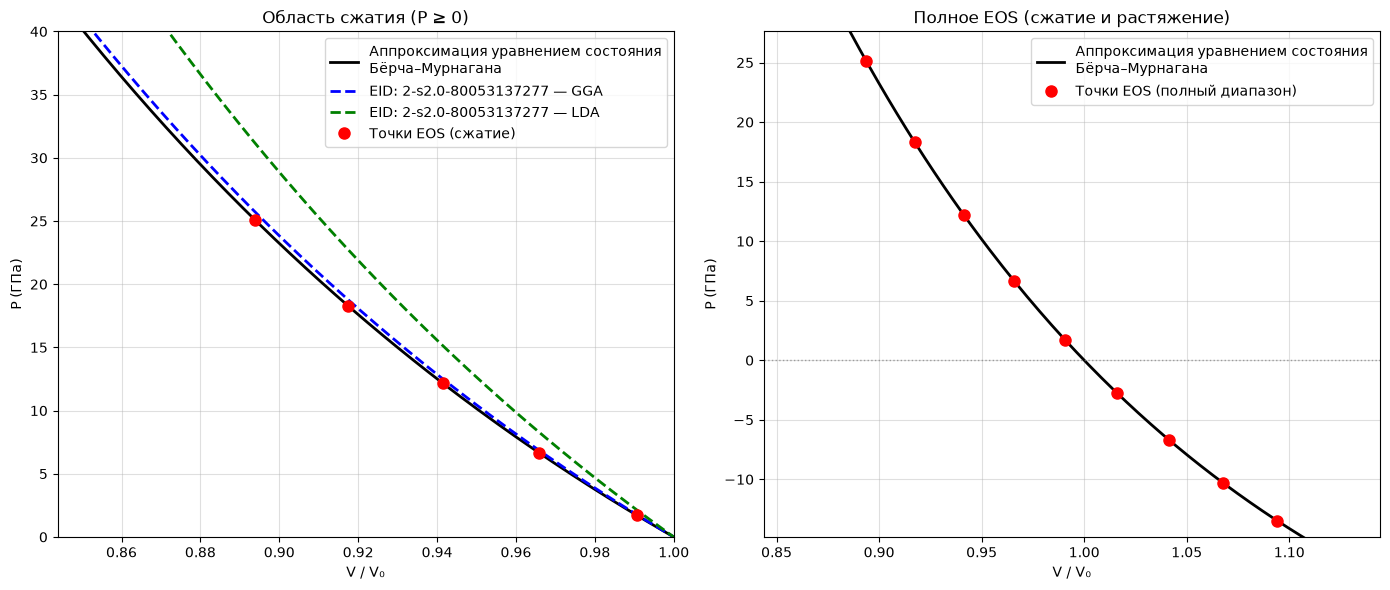

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(v_norm_smooth, p_fit_smooth, 'k-', lw=2, label='Аппроксимация уравнением состояния\nБёрча–Мурнагана')
ax1.plot(df_gga['V / V₀'], df_gga['P (ГПа)'], 'b--', lw=2, label='EID: 2-s2.0-80053137277 — GGA')
ax1.plot(df_lda['V / V₀'], df_lda['P (ГПа)'], 'g--', lw=2, label='EID: 2-s2.0-80053137277 — LDA')
ax1.plot(df_comp['V / V₀'], df_comp['P (ГПа)'], 'ro', ms=8, label='Точки EOS (сжатие)')
ax1.set(xlabel='V / V₀', ylabel='P (ГПа)', title='Область сжатия (P ≥ 0)',
        xlim=(v_lo, 1.0), ylim=(0, 40))
ax1.grid(alpha=0.4)
ax1.legend(loc='upper right')

ax2.plot(v_norm_full, p_fit_full, 'k-', lw=2, label='Аппроксимация уравнением состояния\nБёрча–Мурнагана')
ax2.plot(df_dft['V / V₀'], df_dft['P (ГПа)'], 'ro', ms=8, label='Точки EOS (полный диапазон)')
ax2.axhline(0, color='gray', ls=':', lw=1, alpha=0.7)
ax2.set(xlabel='V / V₀', ylabel='P (ГПа)', title='Полное EOS (сжатие и растяжение)',
         xlim=(v_lo, df_dft['V / V₀'].max() + 0.05),
         ylim=(df_dft['P (ГПа)'].min() * 1.1, df_dft['P (ГПа)'].max() * 1.1))
ax2.grid(alpha=0.4)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

График зависимости давления от нормированного объема из работы "Study of structural, elastic, electronic, optical and thermal properties of Ni3Al" - [EID: 2-s2.0-80053137277](https://www.researchgate.net/publication/249616445_Study_of_structural_elastic_electronic_optical_and_thermal_properties_of_Ni3Al):

<img src="../image/image_01.png" width="1100">

Расчет в статье был выполнен с помощью пакета программного обеспечения **CASTEP**. Значения файла запуска `.param` которые указаны в работе:

|                          | Ni3Al                      | Аналогичный параметр в VASP                                  |
|--------------------------|----------------------------|--------------------------------------------------------------|
| `task`                   | `GeometryOptimization`     | `IBRION`                                                     |
| `xc_functional`          | `PBE` (GGA) / `CAPZ` (LDA) | Файл POTCAR                                                  |
| `pseudopotentials`       | `ultrasoft`                | Файл POTCAR                                                  |
| `cut_off_energy`         | `660` eV                   | `ENCUT`                                                      |
| `kpoint_mp_grid`         | `8 8 8`                    | `KSPACING` или файл KPOINTS                                  |
| `opt_strategy`           | `BFGS`                     | `BFGS`                                                       |
| `etol_conv`              | `5e-6` eV/atom             | `EDIFF`,но в VASP — на всю ячейку, а не на атом              |
| `ftol_conv`              | `0.01` eV/Å                | `EDIFFG`                                                     |
| `stol_conv`              | `0.03` GPa                 | `EDIFFG`, но для максимального компонента тензора напряжений |
| `dtol_conv`              | `1e-4` Å                   | `EDIFFG`, но для максимального смещения атома                |
| `smearing_width`         | `0.3` eV                   | `SIGMA`; `ISMEAR=0`                                          |

Все остальные параметры (например, `spin_polarized`, `optimize_cell` / `ISIF`, `max_iter`, `nelm` и т.п.) в тексте статьи не указаны.


# Изменение полной энергии системы от параметра решётки Ni₃Al

In [23]:
df_energy = pd.DataFrame({
    'a (Å)': a_values,
    'V (Å³)': [a**3 for a in a_values],
    'E (эВ)': energies
})
df_energy

,a (Å),V (Å³),E (эВ)
0,3.4400000000,40.7075840000,-21.8627017500
1,3.4700000000,41.7819230000,-22.0126089300
2,3.5000000000,42.8750000000,-22.1187612200
3,3.5300000000,43.9869770000,-22.1848626200
4,3.5600000000,45.1180160000,-22.2143373200
5,3.5900000000,46.2682790000,-22.2103462700
6,3.6200000000,47.4379280000,-22.1758265800
7,3.6500000000,48.6271250000,-22.1134915100
8,3.6800000000,49.8360320000,-22.0258711700


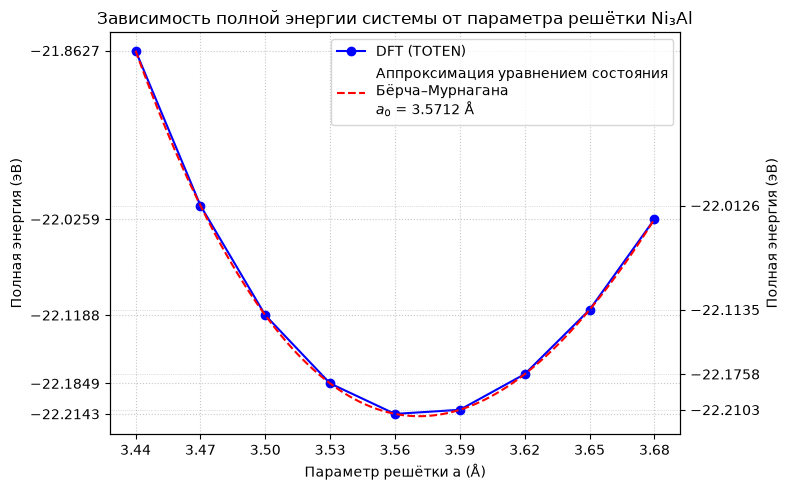

In [24]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(a_values, energies, marker='o', linestyle='-', color='b', label='DFT (TOTEN)')

a_fit = np.linspace(min(a_values), max(a_values), 200)
v_fit = a_fit**3
eta = (v0 / v_fit) ** (2/3)
e_fit = e0 + (9/16) * b0 * v0 * ((eta - 1)**3 * b1 + (eta - 1)**2 * (6 - 4*eta))

ax1.plot(a_fit, e_fit, 'r--', label=f'Аппроксимация уравнением состояния\nБёрча–Мурнагана\n$a_0$ = {a0:.4f} Å')
ax1.set_xlabel('Параметр решётки a (Å)')
ax1.set_ylabel('Полная энергия (эВ)')
ax1.set_title('Зависимость полной энергии системы от параметра решётки Ni₃Al')
ax1.set_xticks(a_values)
ax1.grid(True, linestyle=':', alpha=0.7)

sorted_e = sorted(energies)
left_e = [sorted_e[i] for i in range(len(sorted_e)) if i % 2 == 0]
right_e = [sorted_e[i] for i in range(len(sorted_e)) if i % 2 == 1]
ax1.set_yticks(left_e)
for v in right_e:
    ax1.axhline(y=v, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ax2.set_yticks(right_e)
ax2.set_ylabel('Полная энергия (эВ)')

ax1.legend()
fig.tight_layout()
plt.show()

# Изменение магнитного момента от параметра решётки Ni₃Al

In [25]:
mag_moments = [out.total_mag for out in outcars]

df_mag = pd.DataFrame({
    'a (Å)': a_values,
    'μ_сумм (μ_B)': mag_moments
})
df_mag

,a (Å),μ_сумм (μ_B)
0,3.4400000000,0.6671160000
1,3.4700000000,0.6932331000
2,3.5000000000,0.7133265000
3,3.5300000000,0.7294440000
4,3.5600000000,0.7420623000
5,3.5900000000,0.7542814000
6,3.6200000000,0.7650265000
7,3.6500000000,0.7749742000
8,3.6800000000,0.7811306000


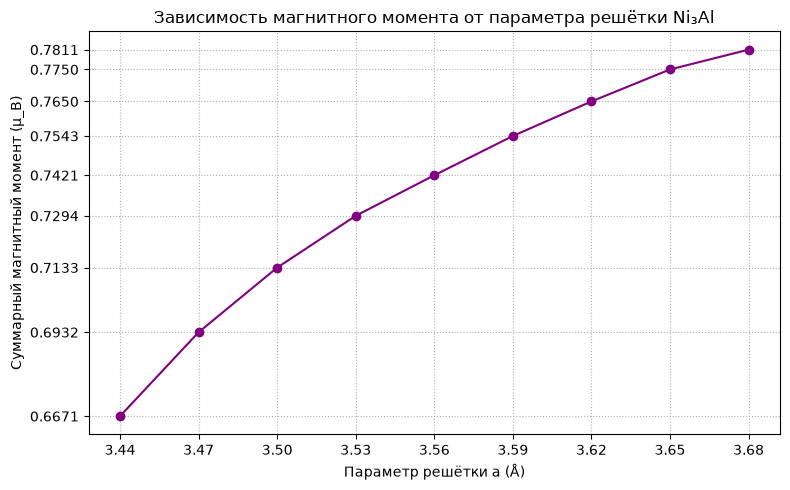

In [26]:
plt.figure(figsize=(8,5))
plt.plot(a_values, mag_moments, 'o-', color='purple')
plt.xlabel('Параметр решётки a (Å)')
plt.ylabel('Суммарный магнитный момент (μ_B)')
plt.title('Зависимость магнитного момента от параметра решётки Ni₃Al')
plt.xticks(a_values)
plt.yticks(mag_moments)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

> Как видно из графика, значения последовательно увеличиваются с ~0.667 до ~0.781 μB. Такой рост объясняется тем, что расчёт стартовал с завышенного начального магнитного момента (`MAGMOM = 1*0.0 3*0.6`), что направило SCF-цикл в метастабильное ферромагнитное состояние — локальный минимум на PES, а не в глобальный (немагнитный). При растяжении решётки межатомные расстояния растут, что изменяет электронную структуру (плотность состояний на уровне Ферми) и может усиливать спиновое расщепление, приводя к увеличению суммарного момента. Эта зависимость не является аномалией, а отражает поведение метастабильной ветви в рамках использованного DFT-подхода.

# Изменение энтальпии образования от параметра решётки Ni₃Al

In [27]:
# Полные энергии на ячейку
TOTEN_Ni = Ni_01_Outcar.final_energy
TOTEN_Al = Al_01_Outcar.final_energy

E_Ni_atom = TOTEN_Ni / 4
E_Al_atom = TOTEN_Al / 4

print(f"E_Ni_atom = {E_Ni_atom:.6f} эВ")
print(f"E_Al_atom = {E_Al_atom:.6f} эВ")

E_Ni_atom = -5.572463 эВ
E_Al_atom = -3.746291 эВ


In [28]:
eV_to_kJ_mol = 96.485

E_form_fu = [e - (3*E_Ni_atom + E_Al_atom) for e in energies]
E_form_kJ_fu = [e * eV_to_kJ_mol for e in E_form_fu]
E_form_kJ_at = [e / 4 for e in E_form_kJ_fu]

df_eos = pd.DataFrame({
    'a (Å)': a_values,
    'E_Ni3Al (эВ)': energies,
    'ΔH_обр (эВ/ф.е.)': E_form_fu,
    'ΔH_обр (кДж/моль ф.е.)': E_form_kJ_fu,
    'ΔH_обр (кДж/моль ат.)': E_form_kJ_at
})
df_eos

,a (Å),E_Ni3Al (эВ),ΔH_обр (эВ/ф.е.),ΔH_обр (кДж/моль ф.е.),ΔH_обр (кДж/моль ат.)
0,3.4400000000,-21.8627017500,-1.3990206250,-134.9845050031,-33.7461262508
1,3.4700000000,-22.0126089300,-1.5489278050,-149.4482992654,-37.3620748164
2,3.5000000000,-22.1187612200,-1.6550800950,-159.6904029661,-39.9226007415
3,3.5300000000,-22.1848626200,-1.7211814950,-166.0681965451,-41.5170491363
4,3.5600000000,-22.2143373200,-1.7506561950,-168.9120629746,-42.2280157436
5,3.5900000000,-22.2103462700,-1.7466651450,-168.5269865153,-42.1317466288
6,3.6200000000,-22.1758265800,-1.7121454550,-165.1963542257,-41.2990885564
7,3.6500000000,-22.1134915100,-1.6498103850,-159.1819549967,-39.7954887492
8,3.6800000000,-22.0258711700,-1.5621900450,-150.7279064918,-37.6819766230


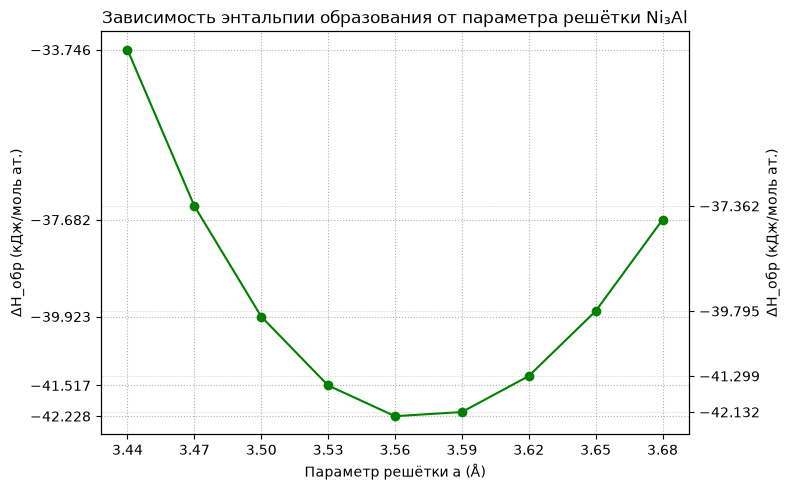

In [29]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(a_values, E_form_kJ_at, 'o-', color='green', label='ΔH_обр')
ax1.set_xlabel('Параметр решётки a (Å)')
ax1.set_ylabel('ΔH_обр (кДж/моль ат.)')
ax1.set_xticks(a_values)
ax1.grid(True, linestyle=':')

sorted_vals = sorted(E_form_kJ_at)
left_ticks = [sorted_vals[i] for i in range(len(sorted_vals)) if i % 2 == 0]
right_ticks = [sorted_vals[i] for i in range(len(sorted_vals)) if i % 2 == 1]
ax1.set_yticks(left_ticks)
for v in right_ticks:
    ax1.axhline(y=v, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ax2.set_yticks(right_ticks)
ax2.set_ylabel('ΔH_обр (кДж/моль ат.)')
ax2.tick_params(axis='y')

plt.title('Зависимость энтальпии образования от параметра решётки Ni₃Al')
fig.tight_layout()
plt.show()

# Плотность состояний (DOS)

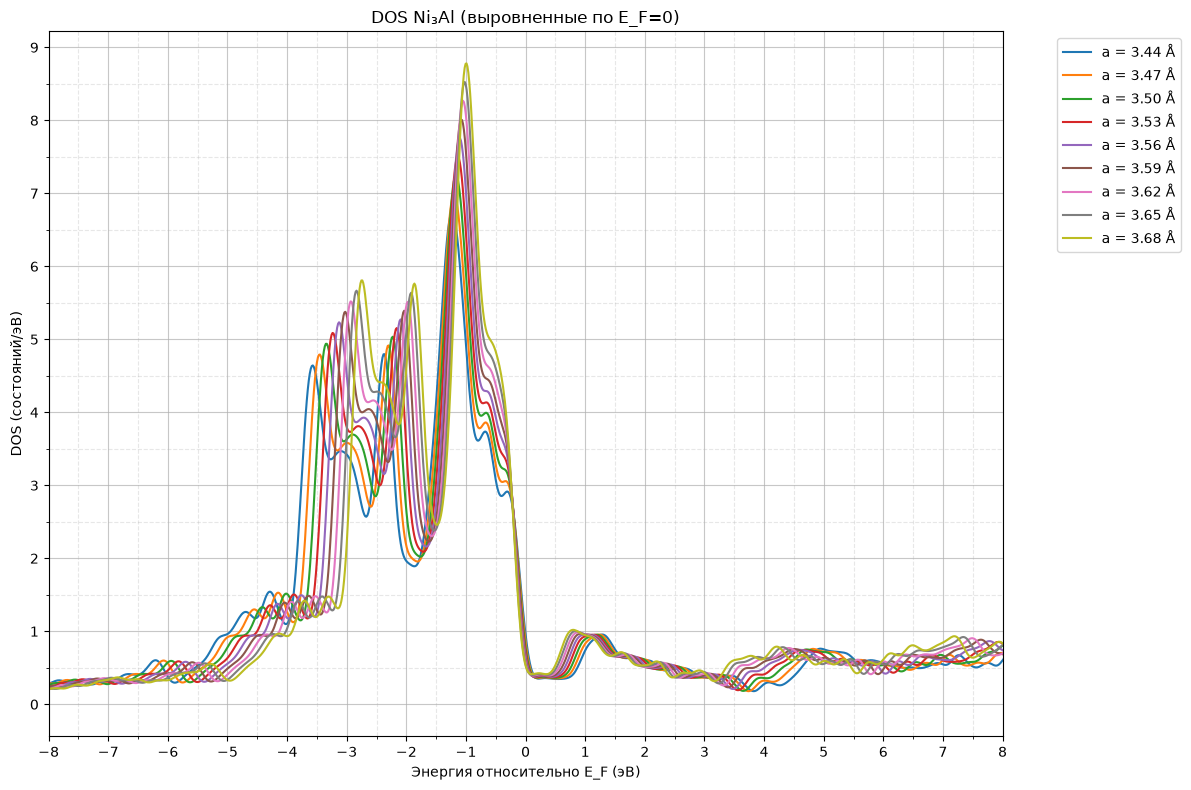

In [30]:
plt.figure(figsize=(12, 8))

for a, vasp, out in zip(a_values, vaspruns, outcars):
    dos = vasp.complete_dos
    dos_energies = dos.energies
    densities = dos.densities[Spin.up]
    efermi = dos.efermi
    plt.plot(dos_energies - efermi, densities, label=f'a = {a:.2f} Å')

plt.xlabel('Энергия относительно E_F (эВ)')
plt.ylabel('DOS (состояний/эВ)')
plt.title('DOS Ni₃Al (выровненные по E_F=0)')
plt.xlim(-8, 8)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

plt.grid(which='major', alpha=0.7, linestyle='-')
plt.grid(which='minor', alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()